In [62]:
import gensim
import numpy as np
import sklearn.metrics
import pandas as pd

In [125]:
def normalize(vector):
    normalized_vector = vector / np.linalg.norm(vector)
    return normalized_vector

def dimension(model, positives, negatives):
    diff = sum([normalize(model[x]) for x in positives]) - sum([normalize(model[y]) for y in negatives])
    return diff

def makeDF(model, word_list):
    isr_pal = []
    for word in word_list:
        isr_pal.append(sklearn.metrics.pairwise.cosine_similarity(model[word].reshape(1,-1), israel_palestine_dim.reshape(1,-1))[0][0])
    df = pd.DataFrame({'Dimension': isr_pal}, index = word_list)
    return df

def Coloring(Series):
    x = Series.values
    y = x-x.min()
    z = y/y.max()
    c = list(plt.cm.rainbow(z))
    return c

def PlotDimension(ax,df, dim):
    ax.set_frame_on(False)
    ax.set_title(dim, fontsize = 20)
    colors = Coloring(df[dim])
    for i, word in enumerate(df.index):
        ax.annotate(word, (0, df[dim][i]), color = colors[i], alpha = 0.6, fontsize = 12)
    MaxY = df[dim].max()
    MinY = df[dim].min()
    plt.ylim(MinY,MaxY)
    plt.yticks(())
    plt.xticks(())

def assign_score (word, df):
    if word in emotional_words_in_sm:
        return df.loc[word]['Dimension']

### Emotional words

In [54]:
dict_path = r"NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"
nrc = pd.read_csv(dict_path, sep="\t", names=["word", "emotion", "association"], encoding = 'ISO-8859-1')
nrc = nrc[nrc.association == 1]

In [148]:
emotional_words = nrc.word.unique().tolist()

emotional_words_in_news = [word for word in emotional_words if word in news_model.wv.key_to_index.keys()]
emotional_words_in_sm = [word for word in emotional_words if word in social_media_model.wv.key_to_index.keys()]


In [147]:
import random
random.seed(1)
emotional_words_in_sm_sample = random.sample(emotional_words_in_sm, 20)
emotional_words_in_news_sample = random.sample(emotional_words_in_news, 20)

ValueError: Sample larger than population or is negative

### Topical words

In [146]:
#get topical words

#from the intercept article
topical_words = ['journalist', 'children', 'boy', 'girl', 'kid', 'reporter', 'nurse', 'child', 'infant', 'disabled', 'elderly', 'orphan', 'mother']

topical_words_in_news = [word for word in topical_words if word in news_model.wv.key_to_index.keys()]
topical_words_in_sm = [word for word in topical_words if word in social_media_model.wv.key_to_index.keys()]


### Verbs

In [ ]:
#relevant verbs
verbs = []

verbs_in_news = [word for word in verbs if word in news_model.wv.vocab]
verbs_in_sm = [word for word in verbs if word in social_media_model.wv.vocab]

### Analysis

In [133]:
#load models
from gensim.models import Word2Vec

news_model = Word2Vec.load("news_word2vec.model")
social_media_model = Word2Vec.load("sm_word2vec.model")

#create list of words
pal_words = [w[0] for w in social_media_model.wv.most_similar('palestine', topn=30) if w[0].startswith('pal')]
pal_words_ham = [w[0] for w in social_media_model.wv.most_similar('hammas', topn=30) if w[0].startswith('ham')]
pal_words = pal_words + pal_words_ham

isr_words = [w[0] for w in social_media_model.wv.most_similar('israel', topn=30) if w[0].startswith('isr')]
isr_words = isr_words + ['idf', 'idfs', 'iof']

# create dimension
israel_palestine_dim = dimension(social_media_model.wv, isr_words, pal_words)

In [150]:
#projections
projection_news_emotion = makeDF(news_model.wv, emotional_words_in_news)
projection_news_topical = makeDF(news_model.wv, topical_words_in_news)
# projection_news_verbs = makeDF(news_model, verbs_in_news)

projection_sm_emotion = makeDF(social_media_model.wv, emotional_words_in_sm_sample)
projection_sm_topical = makeDF(social_media_model.wv, topical_words_in_sm)
# projection_sm_verbs = makeDF(social_media_model, verbs_in_sm)


In [151]:
EmotionDF_sm = makeDF(social_media_model.wv, emotional_words_in_sm)
TopicalDF_sm = makeDF(social_media_model.wv, topical_words_in_sm)

EmotionDF_news = makeDF(news_model.wv, emotional_words_in_news)
TopicalDF_news = makeDF(news_model.wv, topical_words_in_news)


Text(0.5, 1.0, 'Emotion')

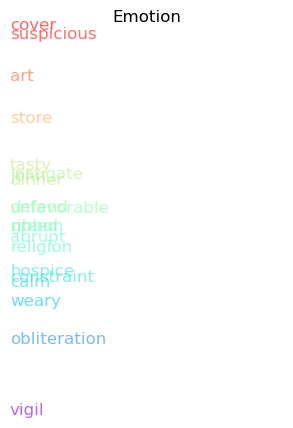

In [141]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (12,5))
ax1 = fig.add_subplot(131)
PlotDimension(ax1, EmotionDF, 'Dimension')
#change title
ax1.set_title('Emotion')

In [124]:
nrc['score'] = nrc['word'].apply(lambda x: assign_score(x, EmotionDF))
nrc_analysis = nrc.dropna()
nrc_analysis

,word,emotion,association,score
23,abandon,fear,1,0.038336
25,abandon,negative,1,0.038336
27,abandon,sadness,1,0.038336
40,abandonment,anger,1,-0.116062
43,abandonment,fear,1,-0.116062
...,...,...,...,...
141399,zeal,trust,1,-0.011323
141414,zealous,joy,1,-0.223573
141416,zealous,positive,1,-0.223573
141419,zealous,trust,1,-0.223573


In [143]:
TopicalDF

,Dimension
journalist,0.161773
children,-0.138924
boy,0.033394
girl,0.036216
kid,-0.033847
reporter,0.220810
nurse,0.089228
child,-0.028074
infant,-0.000471
disabled,-0.029198


In [ ]:
full_yt = pd.read_pickle('full_yt.pkl')
ip_df = pd.read_pickle('ip_df.pkl')

In [154]:
TopicalDF_news

,Dimension
journalist,-0.003856
children,-0.033485
boy,-0.028098
girl,-0.084974
kid,-0.011984
reporter,0.053007
child,-0.179025
infant,-0.109132
disabled,-0.064379
elderly,-0.139030
